In [ ]:
from pathlib import Path

import equinox as eqx
import grain
import jax
import matplotlib.pyplot as plt
from context_flux_no.data import TheWellDataSource
from context_flux_no.training.io import load_model
from tqdm import tqdm


jax.config.update("jax_default_device", jax.devices("gpu")[3])

In [2]:
checkpoint_dir = Path("../../checkpoints/well_euler_2d/")

model_paths = {
    "DPOT": "seed=10/26-04-30-04:59:06",
    "HyperFluxFNOLocal": "seed=10/26-04-30-01:34:48",
    "DISCO": "seed=0/26-04-30-13:56:37",
}

In [3]:
source = TheWellDataSource(
    "../../data/datasets",
    "euler_multi_quadrants_periodicBC",
    "test",
    window_size=20,
    downsample_spatial=8,
    exclude_field_names=["pressure"],
)
sampler = grain.samplers.IndexSampler(len(source), shuffle=True, seed=0)
transforms = [grain.transforms.Batch(batch_size=512)]

In [4]:
dataloader = grain.DataLoader(
    data_source=source,
    sampler=sampler,
    operations=transforms,
    # read_options=grain.ReadOptions(num_threads=32, prefetch_buffer_size=1000),
)

In [5]:
dataiter = iter(dataloader)
batch = next(dataiter)

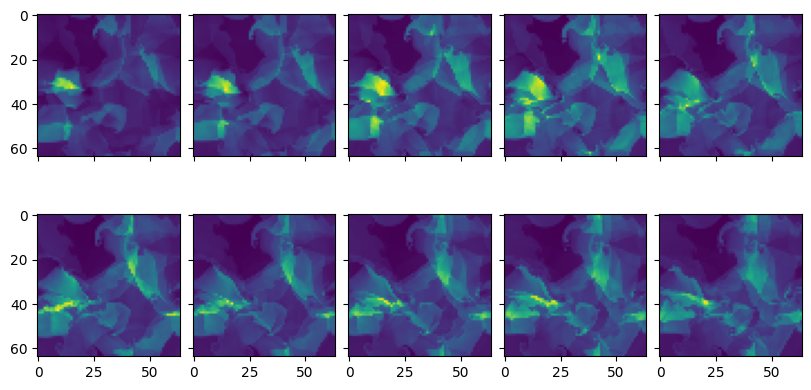

In [6]:
sample_idx = 20
fig, axes = plt.subplots(
    2, 5, figsize=(8, 4), constrained_layout=True, sharex=True, sharey=True
)
for i, ax in enumerate(axes.flat):
    ax.imshow(batch[sample_idx, i, 0])

In [7]:
batch.shape

(512, 20, 4, 64, 64)

In [8]:
len(source)

41000

In [9]:
u_pred_dict = {}

traj_idx = 100
for model_type, path in tqdm(model_paths.items()):
    model = load_model(checkpoint_dir / model_type / "OneStepLoss" / path)
    model = eqx.nn.inference_mode(model, True)

    context, u_data = batch[:, :10], batch[:, 10:]
    u_pred = eqx.filter_vmap(
        lambda x, y: model.rollout(x, (0.015, 1 / 64), num_steps=len(y))[0]
    )(context, u_data)

    u_pred_dict[model_type] = u_pred

  0%|          | 0/3 [00:00<?, ?it/s]

 33%|███▎      | 1/3 [00:42<01:25, 42.63s/it]/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/models/multiphysics/hyperfluxfno/encoders/utils.py:50: UserWarning: TRecViTEncoder supports variable in_timesteps. The given 
                    in_timesteps value will be ignored.
  warnings.warn(


(10, 6, 64, 64)


E0506 00:01:29.222207  258040 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.34 = f32[512,128]{1,0} fusion(mul.275, get-tuple-element.130), kind=kCustom, calls=gemm_fusion_dot.34_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["128","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0506 00:01:29.222301  258040 xtile_compiler.cc:401] Computation: gemm_fusion_dot.34_computation.clone {
  parameter_0.27 = f32[512,128]{1,0} parameter(0)
  parameter_1.27 = f32[128,128]{1,0} parameter(1)
  ROOT dot.73 = f32[512,128]{1,0} dot(parameter_0.27, parameter_1.27), lhs_contracting_dims={1}, rhs_contracting_dims={1}, backend_config={"sizes":["64"]}
}
E0506 00:01:29.562681  258035 xtile_co

In [10]:
u_pred_dict["DPOT"].shape

(512, 10, 4, 64, 64)

Text(0.5, 0.98, 'Rollout=6 step(s)')

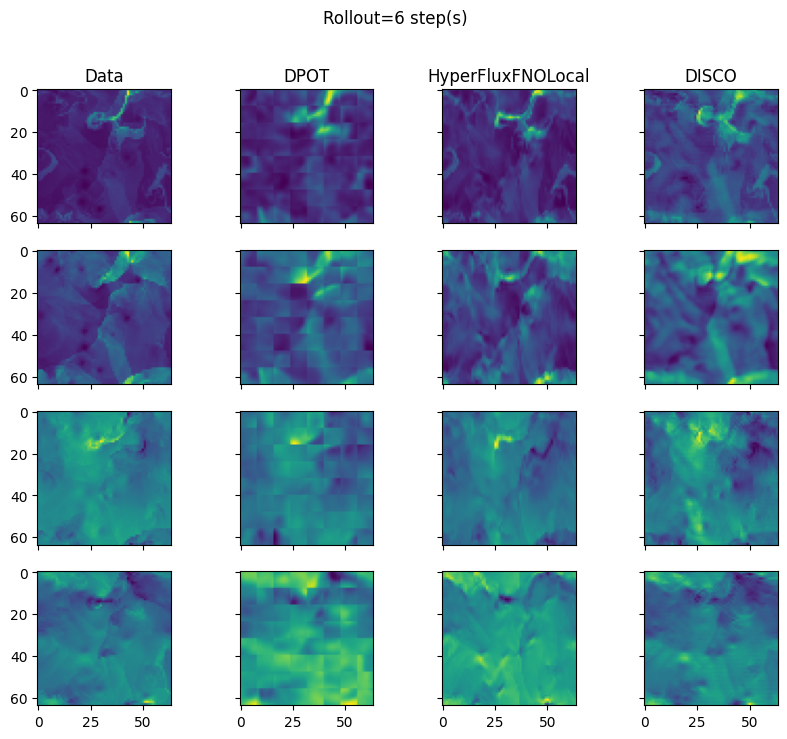

In [17]:
t_idx = 5
sample_idx = 80
fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=True, sharey=True)
axes[0, 0].set_title("Data")
for j in range(4):
    axes[j, 0].imshow(u_data[sample_idx, t_idx, j])
    for i, (model_name, u_pred) in enumerate(u_pred_dict.items()):
        axes[0, i + 1].set_title(model_name)
        axes[j, i + 1].imshow(u_pred[sample_idx, t_idx, j])
fig.suptitle(f"Rollout={t_idx + 1} step(s)")

In [24]:
import jax.numpy as jnp
from context_flux_no.metrics import relative_L2_error


jax.tree.map(
    lambda x: jnp.mean(eqx.filter_vmap(relative_L2_error)(x[:,], u_data[:,])),
    u_pred_dict,
)

{'DISCO': Array(0.23533005, dtype=float32),
 'DPOT': Array(0.22182012, dtype=float32),
 'HyperFluxFNOLocal': Array(0.2977892, dtype=float32)}